# Pipelines
Finalmente vamos a utilizar pipelines para poder mejorar los hiperparametros de un modelo. En particular para este caso vamos a utilizar KNN en su versión no optimizada y luego vamos a optimizarla para comparar resultados.

### SETUP
Instalamos e importamos dependencias, descargamos dataset

In [1]:
%pip install -q scikit-learn
%pip install -q matplotlib
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importamos librerias
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Descargamos dataset y aprovechamos a separar variable objetivo
data = load_iris()
X, y = data.data, data.target

## Preparación del Dataset

Hagamos el split training/testing para utilizar en nuestro pipeline 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Creación del Pipeline
Solo con eso podemos armar el pipeline conformado por un scaler (para normalizar el dataset), un PCA para reducir la dimensionalidad a 2D y un KNN como modelo de predicción. <br>
Luego de eso entrenamos el pipeline con el dataset y obtenemos sus predicciones

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),       
    ('pca', PCA(n_components=2),),       
    ('knn', KNeighborsClassifier(n_neighbors=5,))  
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)


## Estudio de Resultados Pre-Optimizados

Veamos los resultados que obtenemos con el modelo sin optimizar. <br>

Notese que `score()` en el caso de clasificación retorna la exactitud promedio.

----------------------SCORE---------------------- 
 90.0% 
-------------------------------------------------


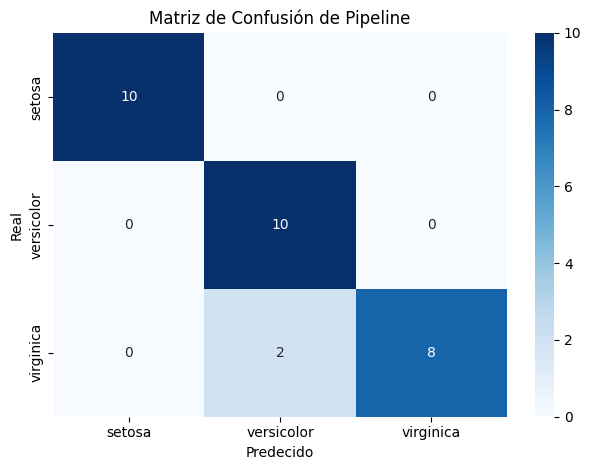

In [24]:
test_score = pipeline.score(X_test, y_test)
print(f"----------------------SCORE---------------------- \n {test_score * 100}% \n-------------------------------------------------")

labels = data.target_names

conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusión de Pipeline')
plt.xlabel('Predecido')
plt.ylabel('Real')

# Show the plot
plt.tight_layout()
plt.show()

Podemos ver que tenemos un modelo bastante certero, con una leve confusión en la diferenciación entre versicolor y virginica. Veamos si la optimización de hiperparametros nos permite obtener mejores resultados. <br>

In [19]:
param_grid = {'pca__n_components': [2, 3],
              'knn__n_neighbors': [3, 5, 7]
             }


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

optimized_model = GridSearchCV(estimator=pipeline,
                          param_grid=param_grid,
                          cv=cv,
                          scoring='accuracy',
                          verbose=2
                         )


optimized_model.fit(X_train, y_train)


y_pred = optimized_model.predict(X_test)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

----------------------SCORE---------------------- 
 93.33% 
-------------------------------------------------


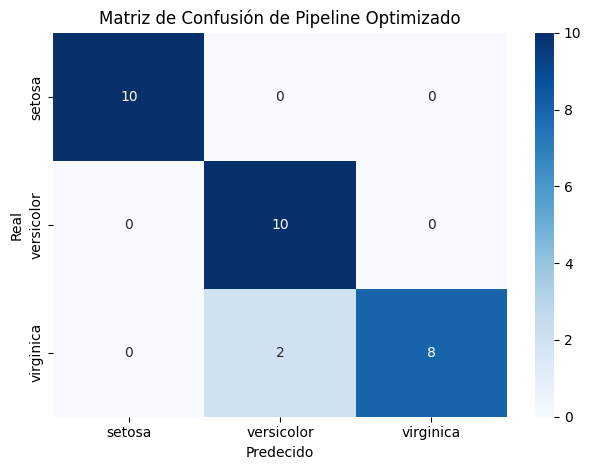

In [25]:
test_score = optimized_model.score(X_test, y_test)
print(f"----------------------SCORE---------------------- \n {test_score * 100:.2f}% \n-------------------------------------------------")

labels = data.target_names

conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

plt.title('Matriz de Confusión de Pipeline Optimizado')
plt.xlabel('Predecido')
plt.ylabel('Real')

# Show the plot
plt.tight_layout()
plt.show()

Podemos ver que nuestro modelo optimizado clasificó correctamente uno de los casos que antes no era capaz de predecir, quizas una única corrección parezca poco, pero podemos ver que el _score_ del mismo incrementó en un 3%, pasando de 90% a 93%.